In [1]:
import os
import pandas as pd
import numpy as np
from rapidfuzz import process, fuzz
import matplotlib.pyplot as plt

# Import dataset

In [2]:
folder = "../data/raw"
ansp_file = "ansp.xlsx"
named_archive_file = "named_archive.xlsx"
rsl_file = "rsl.xlsx"

In [3]:
ansp_hist = pd.read_excel(os.path.join(folder, ansp_file), sheet_name="Historical ANSP", header=2)
ansp_curr = pd.read_excel(os.path.join(folder, ansp_file), sheet_name="Current ANSP", header=2)

In [4]:
named_archive = pd.read_excel(os.path.join(folder, named_archive_file), sheet_name="Historic Disclosures 10.07.2026")

In [5]:
rsl = pd.read_excel(os.path.join(folder, rsl_file), sheet_name="Reportable Shares List")
rsl_removed = pd.read_excel(os.path.join(folder, rsl_file), sheet_name="Recently Removed")

# Data Cleaning

## ANSP

In [6]:
ansp_hist.rename(columns={"Name of Company": "company_name",
                          "International Securities Identification Number (ISIN)": "ISIN",
                          "Aggregated net short position (%)": "agg_net_pos",
                          "Position date": "pos_date",
                          "Date the aggregated net short position became historical": "date_agg_net_pos_hist"},
                inplace=True)
ansp_hist["pos_date"] = pd.to_datetime(ansp_hist["pos_date"], format="%Y-%m-%d")
ansp_hist["date_agg_net_pos_hist"] = pd.to_datetime(ansp_hist["date_agg_net_pos_hist"], format="%Y-%m-%d")
ansp_hist["agg_net_pos"] = ansp_hist["agg_net_pos"]/100
ansp_hist.head()

,company_name,ISIN,agg_net_pos,pos_date,date_agg_net_pos_hist
0,3I GROUP PLC,GB00B1YW4409,0.0110,2026-08-07,2026-08-10
1,3I GROUP PLC,GB00B1YW4409,0.0111,2026-08-06,2026-08-07
2,3I GROUP PLC,GB00B1YW4409,0.0111,2026-08-10,2026-09-22
3,3I GROUP PLC,GB00B1YW4409,0.0140,2026-07-22,2026-07-23
4,3I GROUP PLC,GB00B1YW4409,0.0140,2026-08-05,2026-08-06


In [7]:
ansp_curr.rename(columns={"Name of Company": "company_name",
                          "International Securities Identification Number (ISIN)": "ISIN",
                          "Aggregated net short position (%)": "agg_net_pos",
                          "Position date (of latest position date notified)": "pos_date"},
                inplace=True)
ansp_curr["pos_date"] = pd.to_datetime(ansp_curr["pos_date"], format="%Y-%m-%d")
ansp_curr["agg_net_pos"] = ansp_curr["agg_net_pos"]/100
ansp_curr.head()

,company_name,ISIN,agg_net_pos,pos_date
0,3I GROUP PLC,GB00B1YW4409,0.0110,2026-09-22
1,4IMPRINT GROUP PLC,GB0006640972,0.0040,2026-09-08
2,80 Mile Plc,GB00BFD3VF20,0.0063,2026-09-22
3,A.G. BARR plc,GB00B6XZKY75,0.0083,2026-09-09
4,AB DYNAMICS PLC,GB00B9GQVG73,0.0069,2026-08-12


## RSL

In [8]:
rsl.rename(columns={
    "Share ISIN":"ISIN",
    "Company name":"name",
    "Date added": "date",
    "Class of share (Main or Other Class of Shares)":"share_class"
}, inplace=True)
rsl["date"] = pd.to_datetime(rsl["date"], format="%Y-%m-%d")

In [9]:
rsl.head()

,ISIN,name,date,share_class
0,GB00BFZ45C84,1SPATIAL PLC,2026-07-13,Main
1,GB00B1YW4409,3I GROUP PLC,2026-07-13,Main
2,JE00BF5FX167,3I INFRASTRUCTURE PLC,2026-07-13,Main
3,GB00BMCLYF79,4BASEBIO PLC,2026-07-13,Main
4,GB0006640972,4IMPRINT GROUP PLC,2026-07-13,Main


In [10]:
rsl_removed.rename(columns={
    "Share ISIN":"ISIN",
    "Company name":"name",
    "Date added": "date",
    "Class of share (Main or Other Class of Shares)":"share_class",
    "Date removed": "date_removed"
}, inplace=True)
rsl_removed["date"] = pd.to_datetime(rsl_removed["date"], format="%Y-%m-%d")
rsl_removed["date_removed"] = pd.to_datetime(rsl_removed["date_removed"], format="%Y-%m-%d")

In [11]:
rsl_removed.head()

,ISIN,name,date,share_class,date_removed
0,GG00BQKNKR70,AMEDEO AIR FOUR PLUS LIMITED,2026-07-13,Main,2026-08-03
1,US07724U1034,BEIERSDORF AKTIENGESELLSCHAFT,2026-07-13,Other Class of Shares,2026-08-03
2,DE0005227201,BIOTEST AKTIENGESELLSCHAFT,2026-07-13,Other Class of Shares,2026-08-03
3,GG00BMDGQT90,CORDIANT DIGITAL INFRASTRUCTURE LIMITED,2026-07-13,Other Class of Shares,2026-08-03
4,GG00BSWVSD56,FAIR OAKS INCOME LIMITED,2026-07-13,Other Class of Shares,2026-08-03


## Named Archive

In [12]:
named_archive.rename(columns={"Position Holder": "pos_holder",
                          "Name of Share Issuer": "name_share_issuer",
                          "Net Short Position (%)": "net_short_pos",
                          "Position Date": "pos_date"},
                inplace=True)
named_archive["pos_date"] = pd.to_datetime(named_archive["pos_date"], format="%Y-%m-%d")
named_archive["net_short_pos"] = named_archive["net_short_pos"]/100

In [13]:
clean_issuer_holder = (
    named_archive["name_share_issuer"]
    .str.lower()
    .str.replace(r"[,.]", "", regex=True)
    .str.replace(r"\b(pvt|private|ltd|limited|ph|lp|llp|l.p.|pty|llc|llc|inc|plc|lllp|sa)\b", "", regex=True)
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.strip("_")
    .str.replace(r"_+", "_", regex=True)
)
named_archive["name_share_issuer"] = clean_issuer_holder

In [14]:
clean_pos_holder = (
    named_archive["pos_holder"]
    .str.lower()
    .str.replace(r"[,.]", "", regex=True)
    .str.replace(r"\b(pvt|private|ltd|limited|ph|lp|llp|europe|jersey|ii|pty|llc|llc|inc|plc|lllp|sa|uk|usa|gp|mt)\b", "", regex=True)
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.strip("_")
    .str.replace(r"_+", "_", regex=True)
)
named_archive["pos_holder"] = clean_pos_holder

In [15]:
# checking if all position holders are unique (no duplicates under different name)
unique_names = list(named_archive["pos_holder"].dropna().unique())
pairs = []
seen = set()
for name in unique_names:
    matches = process.extract(
        query=name,
        choices=unique_names,
        scorer=fuzz.token_sort_ratio,
        score_cutoff=95.0,
        limit=10
    )
    for match_name, score, _ in matches:
        if match_name != name:
            pair_key = tuple(sorted([name, match_name]))
            if pair_key not in seen:
                seen.add(pair_key)
                pairs.append({'entity_a': pair_key[0],
                            'entity_b': pair_key[1],
                            'score': score})

pairs # no need of fuzzy match records as all are normalised with no valid fuzzy pairs

[]

In [16]:
# checking if ISIN has only one unique issuer
isin_issuer = named_archive.groupby(["ISIN"])["name_share_issuer"].nunique()
print(f"Any one->many from ISIN->issuer: {(isin_issuer > 1).any()}") # is False -> no one ISIN many issuer combination
issuer_isin = named_archive.groupby(["name_share_issuer"])["ISIN"].nunique()
print(f"Any one->many from issuer->ISIN: {(issuer_isin > 1).any()}") # is True -> there are some one issuer many ISIN combination
# replace the ISIN with unique latest ISIN values
latest_isin = (
    named_archive.sort_values(by="pos_date")
    .drop_duplicates(subset=["name_share_issuer"], keep="last")
    .set_index("name_share_issuer")["ISIN"]
)
issuer_isin = issuer_isin[issuer_isin>1].index
isin_mapping = latest_isin[latest_isin.index.isin(issuer_isin)]
named_archive["ISIN"] = named_archive["name_share_issuer"].map(isin_mapping).fillna(named_archive["ISIN"])

Any one->many from ISIN->issuer: False
Any one->many from issuer->ISIN: True


In [17]:
named_archive.head()

,pos_holder,name_share_issuer,ISIN,net_short_pos,pos_date
0,alphagen_capital,1spatial,GB00B09LQS34,0.0000,2013-06-24
1,alphagen_capital,1spatial,GB00B09LQS34,0.0142,2013-05-29
2,alphagen_capital,1spatial,GB00B09LQS34,0.0071,2013-05-24
3,bronte_capital_management,4d_pharma,GB00BJL5BR07,0.0044,2022-03-18
4,bronte_capital_management,4d_pharma,GB00BJL5BR07,0.0050,2022-01-24


In [18]:
# build panel data, showcasing position holder's position in ISIN at month end
df = named_archive.sort_values(["pos_holder", "ISIN", "pos_date"])
df = df.drop_duplicates(["pos_holder", "ISIN", "pos_date"], keep="last")

month_ends = pd.date_range(df.pos_date.min(), "2026-07-10", freq="ME")
snaps = []
for d in month_ends:
    last = df[df.pos_date<=d].groupby(["pos_holder", "ISIN"]).tail(1)
    snaps.append(last[last.net_short_pos>=0.005].assign(month_end=d))
panel_df = pd.concat(snaps, ignore_index=True)

In [19]:
panel_df.head()

,pos_holder,name_share_issuer,ISIN,net_short_pos,pos_date,month_end
0,artemis_investment_management,icap,GB0033872168,0.0052,2012-10-31,2012-10-31
1,pelham_long_short_master_fund,j_sainsbury,GB00B019KW72,0.0076,2012-10-31,2012-10-31
2,samlyn_capital,weir_group_the,GB0009465807,0.0062,2012-10-31,2012-10-31
3,stephen_james,ip_group,GB00B128J450,0.0099,2012-10-31,2012-10-31
4,ako_capital,pace,GB0006672785,0.0412,2012-11-20,2012-11-30


In [20]:
end = named_archive.pos_date.max()
last = named_archive.sort_values("pos_date").groupby(["pos_holder", "ISIN"]).tail(1)
cand = last[last.net_short_pos>=0.005].copy()

cand["holder_last"] = cand.pos_holder.map(named_archive.groupby("pos_holder").pos_date.max())
cand["ISIN_last"] = cand.ISIN.map(named_archive.groupby("ISIN").pos_date.max())
for c in ["pos_date", "holder_last", "ISIN_last"]:
    cand[f"m_{c}"] = (end - cand[c]).dt.days / 30.4

In [21]:
shortlist = cand[(cand.m_ISIN_last>12) | (~cand.ISIN.isin(rsl.ISIN))].ISIN.unique()

In [22]:
gone = pd.read_csv("../data/manual/dilisted_manual.csv", parse_dates=["gone_date"])
cand = cand.merge(gone[["ISIN", "gone_date"]], on="ISIN", how="left")
cand["status"] = np.select(
    [cand.gone_date.notna(), cand.m_holder_last>12],
    ["definite", "probable"],
    default="uncertain"
)
print(cand.status.value_counts())

status
uncertain    581
definite      75
probable       7
Name: count, dtype: int64


In [23]:
cand.loc[(cand.status == "uncertain") & (cand.m_pos_date <= 6), "status"] = "active"
print(cand.status.value_counts())

status
active       563
definite      75
uncertain     18
probable       7
Name: count, dtype: int64


In [24]:
cand[cand.status == "uncertain"].sort_values("net_short_pos", ascending=False)[
    ["pos_holder", "ISIN", "net_short_pos", "pos_date", "m_holder_last", "m_ISIN_last", "m_pos_date"]]

,pos_holder,ISIN,net_short_pos,pos_date,m_holder_last,m_ISIN_last,m_pos_date
76,helikon_investments,GB00BZC0LC10,0.0281,2025-08-29,0.000000,10.328947,10.328947
75,helikon_investments,GB00B18S7B29,0.0157,2025-08-08,0.000000,11.019737,11.019737
72,caxton_associates,GB00BRJQ8J25,0.0109,2025-07-22,11.578947,1.578947,11.578947
92,elliott_investment_management,GB0000456144,0.0090,2025-12-22,4.572368,6.546053,6.546053
82,d1_capital_partners,GB00B3MBS747,0.0084,2025-09-22,9.539474,0.000000,9.539474
88,arrowstreet_capital_partnership,GB00B1XH2C03,0.0069,2025-12-02,0.000000,7.203947,7.203947
79,elliott_management_corporation,GB00BP6MXD84,0.0069,2025-09-09,9.967105,4.572368,9.967105
65,arrowstreet_capital_partnership,GB00B3MBS747,0.0062,2025-01-14,0.000000,0.000000,17.796053
85,quantum_ireland_capital_management,GB00B2863827,0.0062,2025-11-06,8.059211,0.032895,8.059211
80,arrowstreet_capital_partnership,GB00BRJQ8J25,0.0060,2025-09-16,0.000000,1.578947,9.736842


In [25]:
# manually verified that uncertain are infact still active
cand.loc[(cand.status == "uncertain"), "status"] = "active"
print(cand.status.value_counts())

status
active      581
definite     75
probable      7
Name: count, dtype: int64


In [26]:
cand["close_base"] = cand.gone_date # close only definite
cand["close_strict"] = cand.gone_date.fillna(cand.holder_last.where(cand.status=="probable")) # close probable too

def apply_close(df, cand, col):
    p = df.merge(cand[["ISIN", "pos_holder", col]], on=["ISIN", "pos_holder"], how="left")
    keep = p[col].isna() | (p.month_end <= p[col]+pd.offsets.MonthEnd(0))
    return p[keep].drop(columns=col)

panel_base = apply_close(panel_df, cand, "close_base")
panel_strict = apply_close(panel_df, cand, "close_strict")

In [30]:
panel_base.head()

,pos_holder,name_share_issuer,ISIN,net_short_pos,pos_date,month_end
0,artemis_investment_management,icap,GB0033872168,0.0052,2012-10-31,2012-10-31
1,pelham_long_short_master_fund,j_sainsbury,GB00B019KW72,0.0076,2012-10-31,2012-10-31
2,samlyn_capital,weir_group_the,GB0009465807,0.0062,2012-10-31,2012-10-31
3,stephen_james,ip_group,GB00B128J450,0.0099,2012-10-31,2012-10-31
4,ako_capital,pace,GB0006672785,0.0412,2012-11-20,2012-11-30


In [29]:
cand.head()

,pos_holder,name_share_issuer,ISIN,net_short_pos,pos_date,holder_last,ISIN_last,m_pos_date,m_holder_last,m_ISIN_last,gone_date,status,close_base,close_strict
0,anthion_management,valiant_petroleum,GB00B2NJD643,0.0190,2013-03-07,2013-03-07,2013-03-07,160.263158,160.263158,160.263158,2013-04-19,definite,2013-04-19,2013-04-19
1,quantatative,renovo_group,GB00B081NX89,0.0069,2013-08-23,2013-08-23,2013-08-23,154.703947,154.703947,154.703947,2016-02-18,definite,2016-02-18,2016-02-18
2,aqr_capital_management,eurasian_natural_resources,GB00B29BCK10,0.0066,2013-09-19,2026-07-09,2013-09-19,153.815789,0.000000,153.815789,2013-11-25,definite,2013-11-25,2013-11-25
3,bain_capital_public_equity_management,weir_group_the,GB0009465807,0.0096,2013-12-11,2013-12-11,2026-07-07,151.085526,151.085526,0.065789,NaT,probable,NaT,2013-12-11
4,oxford_asset_management,f_c_asset_management,GB0004658141,0.0068,2014-03-20,2018-12-21,2014-03-20,147.828947,90.690789,147.828947,2014-05-08,definite,2014-05-08,2014-05-08


Text(0.5, 1.0, 'Open positions per month')

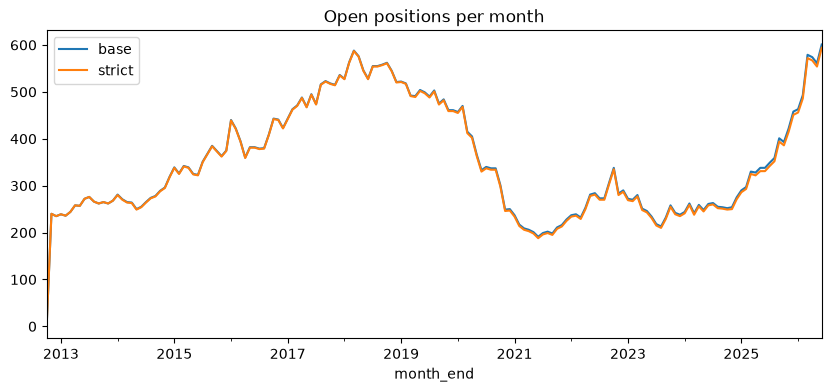

In [27]:
for name, p in [("base", panel_base), ("strict", panel_strict)]:
    p.groupby("month_end").size().plot(label=name, figsize=(10, 4))
plt.legend(); plt.title("Open positions per month")

<Axes: xlabel='month_end'>

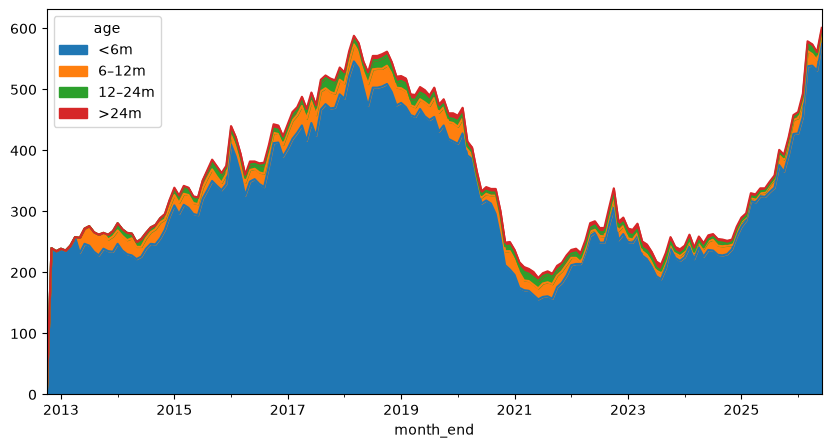

In [28]:
p = panel_base.copy()
p["age_m"] = (p.month_end - p.pos_date).dt.days / 30.4
p["age"] = pd.cut(p.age_m, [-1, 6, 12, 24, 1e9], labels=["<6m", "6–12m", "12–24m", ">24m"])
p.groupby(["month_end", "age"], observed=True).size().unstack().plot.area(figsize=(10, 5))

In [34]:
print(p.head())

                      pos_holder name_share_issuer          ISIN  \
0  artemis_investment_management              icap  GB0033872168   
1  pelham_long_short_master_fund       j_sainsbury  GB00B019KW72   
2                 samlyn_capital    weir_group_the  GB0009465807   
3                  stephen_james          ip_group  GB00B128J450   
4                    ako_capital              pace  GB0006672785   

   net_short_pos   pos_date  month_end     age_m  age  
0         0.0052 2012-10-31 2012-10-31  0.000000  <6m  
1         0.0076 2012-10-31 2012-10-31  0.000000  <6m  
2         0.0062 2012-10-31 2012-10-31  0.000000  <6m  
3         0.0099 2012-10-31 2012-10-31  0.000000  <6m  
4         0.0412 2012-11-20 2012-11-30  0.328947  <6m  


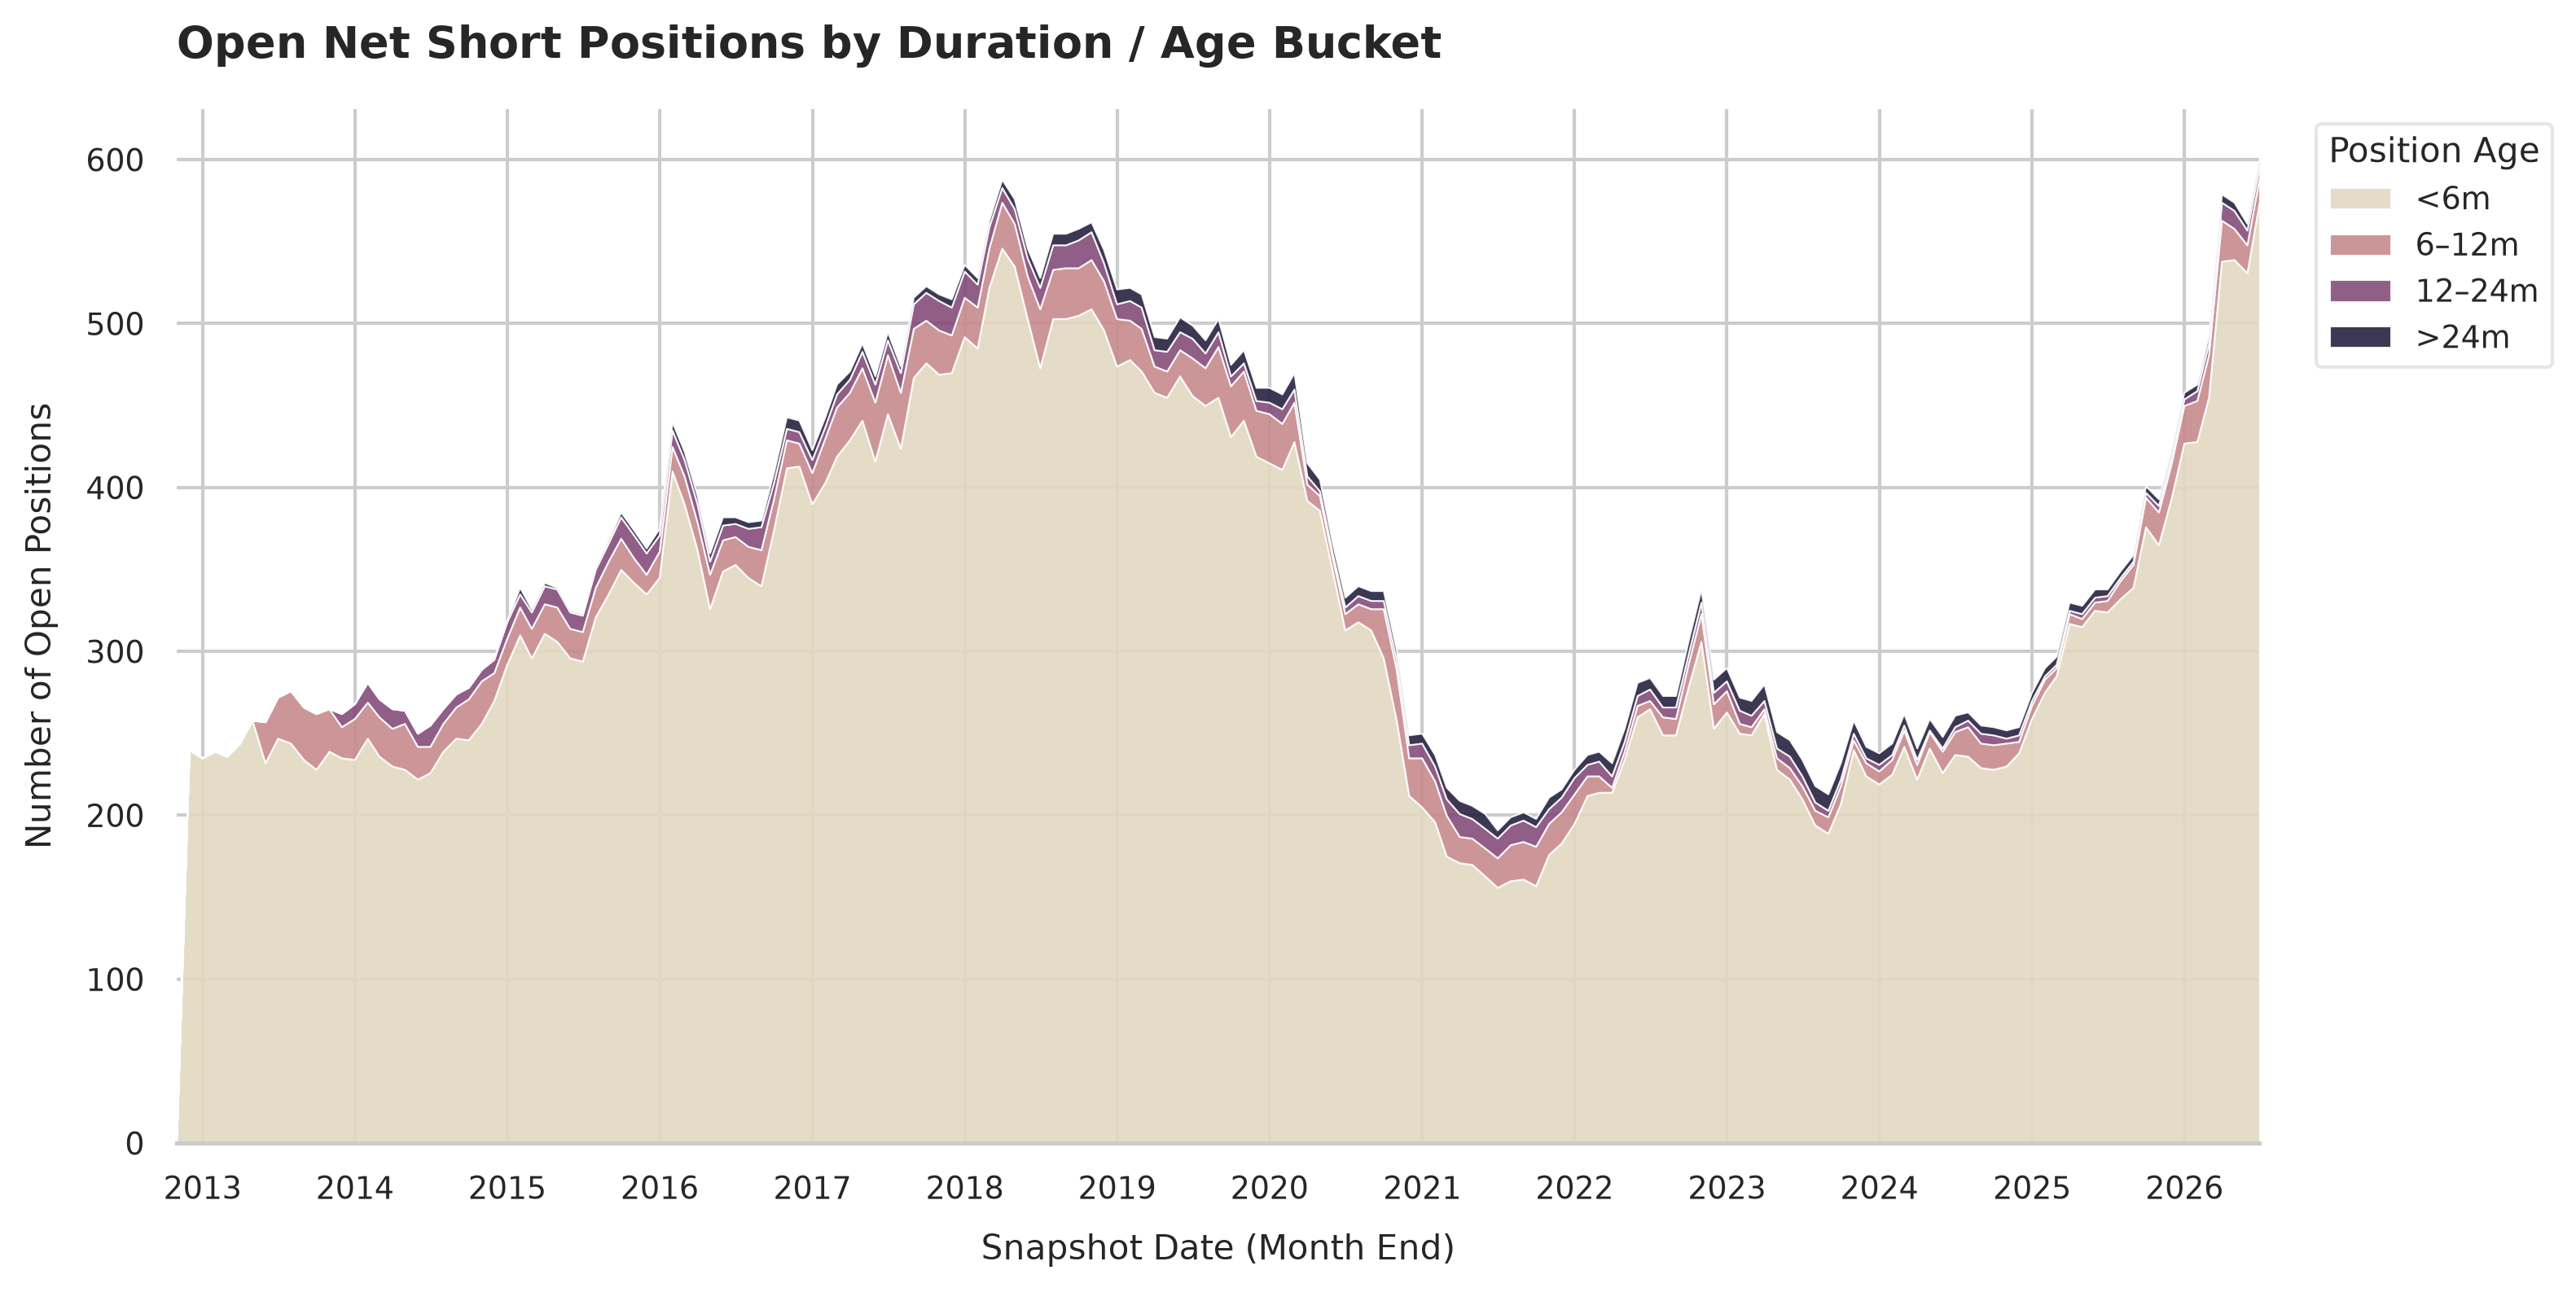

In [35]:
import seaborn as sns
import matplotlib.dates as mdates
p["month_end"] = pd.to_datetime(p["month_end"])

data = (
    p.groupby(["month_end", "age"], observed=True)
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# 2. Seaborn aesthetic configuration
sns.set_theme(style="whitegrid", font="sans-serif")
fig, ax = plt.subplots(figsize=(11, 5.5), dpi=300)

# Professional sequential palette matching the ordinal age buckets
palette = sns.color_palette("ch:s=-.2,r=.6", n_colors=data.shape[1])

# 3. Stacked area plot
ax.stackplot(
    data.index,
    data.values.T,
    labels=data.columns,
    colors=palette,
    alpha=0.9,
    edgecolor="white",
    linewidth=0.5,
)

# 4. Refined styling & labels
ax.set_title(
    "Open Net Short Positions by Duration / Age Bucket",
    fontsize=13,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax.set_xlabel("Snapshot Date (Month End)", fontsize=10, labelpad=8)
ax.set_ylabel("Number of Open Positions", fontsize=10, labelpad=8)

# Format X-axis for clean timeline intervals
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.tick_params(axis="both", which="major", labelsize=9)

# Format Y-axis with commas (e.g., 1,000)
ax.yaxis.set_major_formatter("{x:,.0f}")

# Tight boundaries and spine clean-up
ax.set_xlim(data.index.min(), data.index.max())
ax.margins(y=0.05)
sns.despine(left=True, bottom=False)

# Place legend outside the main plotting area
ax.legend(
    title="Position Age",
    title_fontsize="10",
    fontsize=9,
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
)